<a href="https://colab.research.google.com/github/AlvaroSepul/Entrega2/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd
import json
import numpy as np

# Abrir archivo JSON local
with open("TelecomX_Data.json", "r", encoding="utf-8") as archivo:
    data = json.load(archivo)



#🔧 Transformación

In [ ]:
# Convertir JSON a DataFrame plano
df = pd.json_normalize(data)

# -------------------------
# 1. Revisar problemas
# -------------------------
print("Primeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

# -------------------------
# 2. Limpieza básica
# -------------------------

# Reemplazar vacíos por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Convertir columnas numéricas
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")
df["account.Charges.Monthly"] = pd.to_numeric(df["account.Charges.Monthly"], errors="coerce")
df["customer.tenure"] = pd.to_numeric(df["customer.tenure"], errors="coerce")

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar filas sin dato en Churn
df = df[df["Churn"].notna()].copy()

# Si tenure = 0 y Total está vacío, rellenar con 0
df.loc[
    (df["customer.tenure"] == 0) & (df["account.Charges.Total"].isna()),
    "account.Charges.Total"
] = 0

# -------------------------
# 3. Crear Cuentas_Diarias
# -------------------------
df["Cuentas_Diarias"] = (df["account.Charges.Monthly"] / 30).round(2)

# =========================
# 4. Estandarización básica
# =========================

# Renombrar columnas
df = df.rename(columns={
    "customerID": "ID_Cliente",
    "Churn": "Abandono",
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "Adulto_Mayor",
    "customer.Partner": "Pareja",
    "customer.Dependents": "Dependientes",
    "customer.tenure": "Meses_Cliente",
    "account.Contract": "Tipo_Contrato",
    "account.PaymentMethod": "Metodo_Pago",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total"
})

# Revisar valores antes de transformar
print("Valores originales de Abandono:")
print(df["Abandono"].value_counts(dropna=False))

# Convertir Yes/No a 1/0
columnas_binarias = ["Abandono", "Pareja", "Dependientes"]

for col in columnas_binarias:
    df[col] = df[col].astype(str).str.strip().map({"Yes": 1, "No": 0})

# Traducir género
df["Genero"] = df["Genero"].replace({
    "Male": "Masculino",
    "Female": "Femenino"
})

# Revisar resultado final
print("\nValores transformados de Abandono:")
print(df["Abandono"].value_counts(dropna=False))

print("\nBase final:")
print(df.head())

print("\nNulos finales:")
print(df.isna().sum())

print("\nInformación final:")
print(df.info())


Primeras filas:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.Inter

#📊 Carga y análisis


Resumen descriptivo:
                    mean   median      std    min      max
Meses_Cliente      32.37    29.00    24.56   0.00    72.00
Cargo_Mensual      64.76    70.35    30.09  18.25   118.75
Cargo_Total      2279.73  1394.55  2266.79   0.00  8684.80
Cuentas_Diarias     2.16     2.34     1.00   0.61     3.96

Resumen descriptivo completo:
       Meses_Cliente  Cargo_Mensual  Cargo_Total  Cuentas_Diarias
count        7043.00        7043.00      7043.00          7043.00
mean           32.37          64.76      2279.73             2.16
std            24.56          30.09      2266.79             1.00
min             0.00          18.25         0.00             0.61
25%             9.00          35.50       398.55             1.18
50%            29.00          70.35      1394.55             2.34
75%            55.00          89.85      3786.60             2.99
max            72.00         118.75      8684.80             3.96


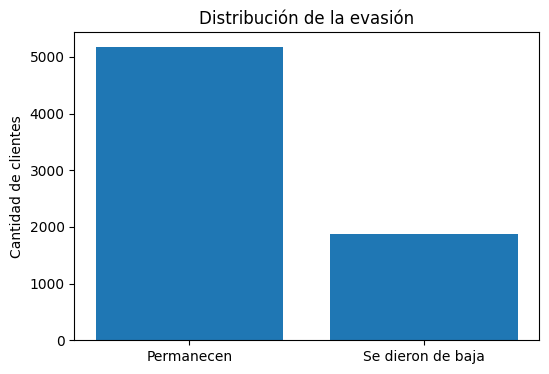

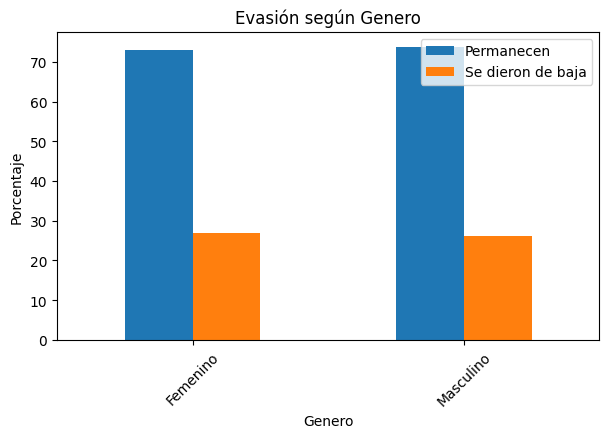

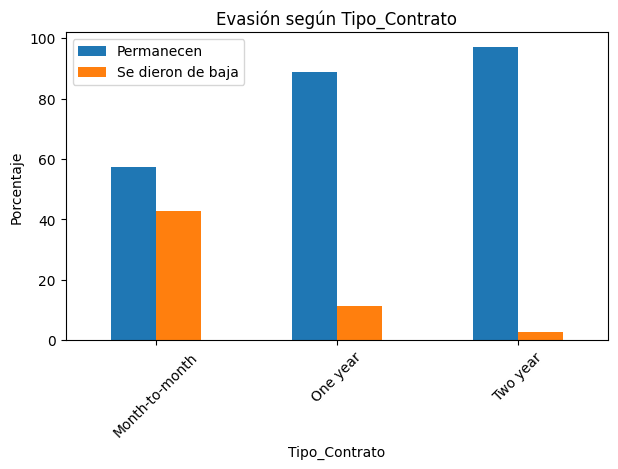

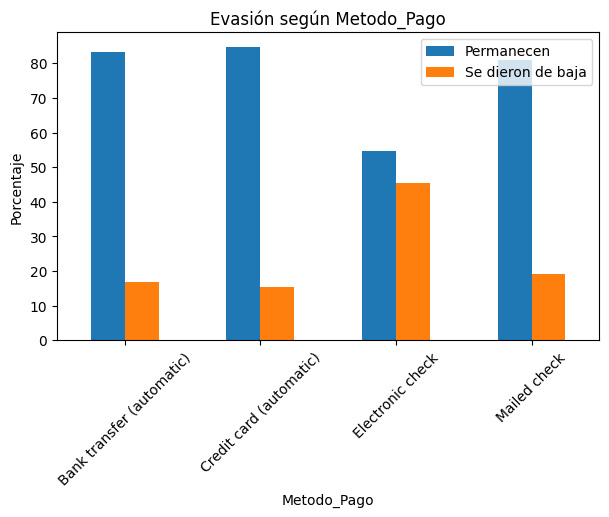

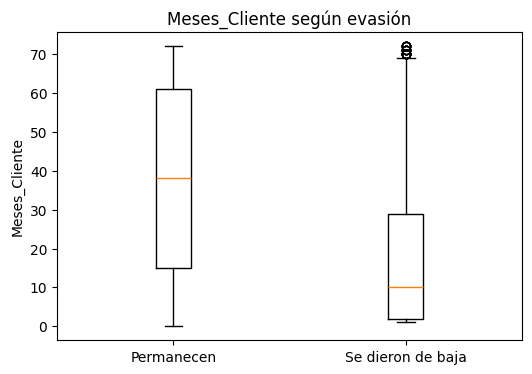

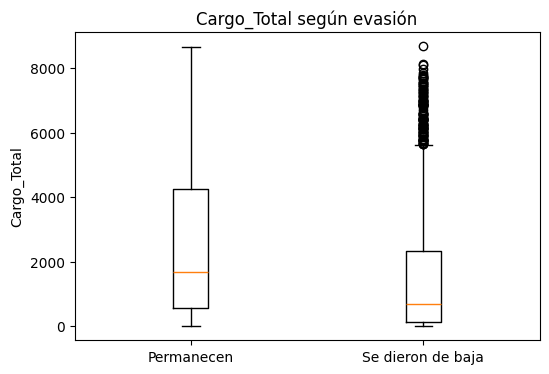

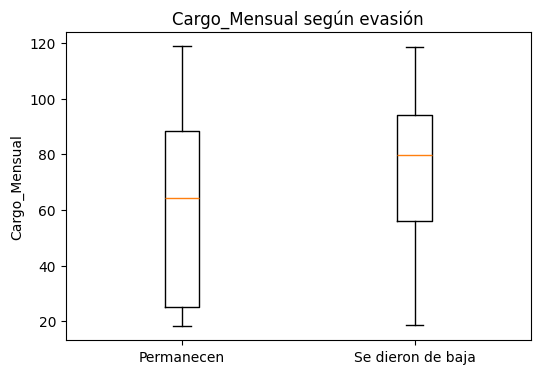

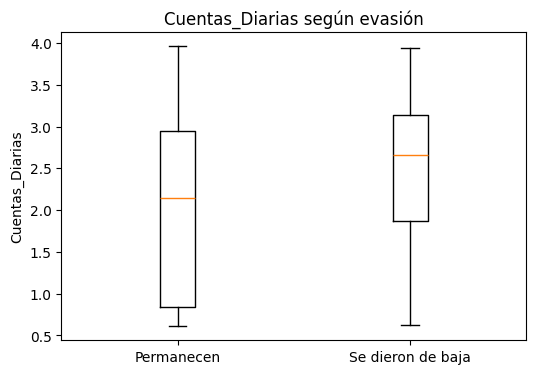

Análisis finalizado


In [34]:
# =========================
# 5. Análisis descriptivo
# =========================

columnas_numericas = ["Meses_Cliente", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"]

resumen = df[columnas_numericas].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
]).T.round(2)

print("\nResumen descriptivo:")
print(resumen)

print("\nResumen descriptivo completo:")
print(df[columnas_numericas].describe().round(2))


# =========================
# 6. Distribución de la evasión
# =========================

conteo_abandono = df["Abandono"].value_counts().reindex([0, 1], fill_value=0)

plt.figure(figsize=(6,4))
plt.bar(["Permanecen", "Se dieron de baja"], conteo_abandono.values)
plt.title("Distribución de la evasión")
plt.ylabel("Cantidad de clientes")
plt.show()


# =========================
# 7. Evasión según variables categóricas
# =========================

variables_categoricas = ["Genero", "Tipo_Contrato", "Metodo_Pago"]

for col in variables_categoricas:
    tabla = pd.crosstab(df[col], df["Abandono"], normalize="index") * 100
    tabla = tabla.reindex(columns=[0, 1], fill_value=0)

    tabla.plot(kind="bar", figsize=(7,4))
    plt.title(f"Evasión según {col}")
    plt.ylabel("Porcentaje")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(["Permanecen", "Se dieron de baja"])
    plt.show()


# =========================
# 8. Evasión según variables numéricas
# =========================

variables_numericas = ["Meses_Cliente", "Cargo_Total", "Cargo_Mensual", "Cuentas_Diarias"]

for col in variables_numericas:
    grupo_0 = df[df["Abandono"] == 0][col].dropna()
    grupo_1 = df[df["Abandono"] == 1][col].dropna()

    plt.figure(figsize=(6,4))
    plt.boxplot([grupo_0, grupo_1], tick_labels=["Permanecen", "Se dieron de baja"])
    plt.title(f"{col} según evasión")
    plt.ylabel(col)
    plt.show()

print("Análisis finalizado")

#📄Informe final

# Informe final – Análisis de evasión de clientes en Telecom X

## 1. Introducción
El objetivo de este trabajo fue analizar la evasión de clientes en Telecom X, es decir, entender mejor qué factores podrían estar asociados a que un cliente decida cancelar el servicio.

Este tipo de análisis es importante porque la evasión afecta directamente los ingresos y la estabilidad de la cartera de clientes. Por eso, revisar los datos y buscar patrones puede ayudar a identificar perfiles con mayor riesgo de abandono y, a partir de eso, pensar en acciones para mejorar la retención.

---

## 2. Limpieza y tratamiento de datos
Lo primero fue cargar la base de datos en formato JSON y transformarla en un DataFrame para poder trabajarla de manera más ordenada en Python.

Después de eso, se hizo una revisión general para detectar posibles problemas que pudieran afectar el análisis. En esta etapa se revisaron valores nulos, campos vacíos, duplicados y tipos de datos. A partir de esa revisión, se hicieron algunos ajustes básicos: se reemplazaron valores vacíos por nulos, se convirtieron columnas numéricas al formato correcto y se eliminaron registros duplicados o incompletos en la variable de evasión.

También se corrigieron algunos casos puntuales, como clientes con antigüedad igual a cero y cargo total vacío, rellenando ese valor con cero para mantener coherencia en los datos.

Luego se creó la columna Cuentas_Diarias, calculada a partir del cargo mensual dividido por 30, con el objetivo de tener una referencia diaria aproximada del gasto del cliente.

Por último, se hizo una estandarización básica de la base, renombrando algunas columnas para que fueran más fáciles de interpretar y transformando ciertas variables categóricas en formatos más simples para el análisis.

---

## 3. Análisis exploratorio de datos
Una vez que la base quedó limpia, se realizó un análisis descriptivo de las variables numéricas principales, como la antigüedad del cliente, el cargo mensual, el cargo total y la nueva variable de cuentas diarias. Para esto se calcularon medidas como media, mediana, desviación estándar, mínimo y máximo. Esta primera revisión permitió entender mejor cómo se distribuyen los datos y qué tan dispersos están los valores.

Después se analizó la variable de evasión de manera general, usando un gráfico para ver cuántos clientes permanecen y cuántos se dieron de baja. Este paso fue importante para dimensionar el problema y ver si la evasión representa una parte pequeña o relevante dentro del total de clientes.

A continuación, se revisó cómo se comporta la evasión según algunas variables categóricas, especialmente:
- género,
- tipo de contrato,
- método de pago.

Estos gráficos permitieron comparar visualmente si ciertos grupos concentran una mayor proporción de bajas que otros.

Finalmente, también se compararon variables numéricas entre clientes que permanecen y clientes que cancelaron, utilizando gráficos para observar diferencias en aspectos como el tiempo de permanencia o el gasto. Esta parte ayudó a ver si existen comportamientos distintos entre ambos grupos.

---

## 4. Conclusiones e insights
A partir del análisis realizado, se puede decir que la evasión no ocurre de manera completamente aleatoria, sino que parece concentrarse más en ciertos tipos de clientes.

Al revisar los gráficos y comparaciones, se observan diferencias entre quienes permanecen y quienes cancelan, tanto en variables categóricas como numéricas. Esto sugiere que características como el tipo de contrato, la forma de pago o la antigüedad del cliente pueden estar relacionadas con una mayor probabilidad de abandono.

Más allá de un resultado puntual, lo importante es que el análisis permitió detectar señales útiles para entender mejor el comportamiento de los clientes. Esto entrega una base inicial bastante valiosa para seguir profundizando en el problema y orientar mejor futuras acciones comerciales o de fidelización.

---

## 5. Recomendaciones
En base a lo observado, una primera recomendación es poner mayor atención en los grupos que muestran una mayor proporción de evasión, ya que ahí probablemente exista una oportunidad concreta de mejora.

También sería útil revisar con más detalle las condiciones comerciales asociadas a esos clientes, por ejemplo el tipo de contrato o el método de pago, para evaluar si hay elementos de la experiencia o de la oferta que podrían estar influyendo en la decisión de cancelar.

Además, como siguiente paso, sería recomendable profundizar este análisis con técnicas más avanzadas, por ejemplo construyendo un modelo predictivo de churn. Eso permitiría anticipar qué clientes tienen mayor riesgo de abandono y actuar antes de que se den de baja.

---

## 6. Cierre
En resumen, este trabajo permitió transformar una base de datos en información útil para entender mejor la evasión de clientes en Telecom X. La limpieza de datos, la creación de nuevas variables y el análisis exploratorio ayudaron a identificar patrones relevantes y a generar una primera base de conclusiones para apoyar la toma de decisiones.

Si bien este análisis no explica por sí solo todas las causas de la evasión, sí aporta una visión clara y ordenada del problema, y deja abierto el camino para seguir profundizando con nuevos análisis.